# Systematic selection of CV per-perturbation values

In [1]:
%load_ext autoreload
%autoreload 2
import sys

sys.path.append('../../')

In [12]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pyaldata as pyal
import tools.dsp as dsp
from tools.params import Params
import tools.dimensionality as dim
import tools.dataTools as dt
from tools.params import colors
import tools.kinematics as kin

from tqdm import tqdm
import tools.viz.utilityTools as vizutils



## Stage 1 — build a pooled per-trial CV table across sessions

Load each session once, compute its own `otsu_thresh` (speed scale is session/animal-specific, so this can't be pooled), then keep only `(session, trial_id, mean_speed, cv)` — no `bhv`/spikes retained. Each session's raw data lives inside `build_session_cv_table`'s local scope, so it's freed automatically once that call returns and before the next session loads. Saved to `pooled_cv.csv` so everything below this (sampling, labeling, sweeping) can run without touching raw data again.

In [13]:
def _find_repo_root(marker="pyproject.toml"):
    # walk up from the kernel's cwd (varies depending on how Jupyter was launched)
    path = Path.cwd().resolve()
    for parent in [path, *path.parents]:
        if (parent / marker).exists():
            return parent
    raise RuntimeError(f"Could not find repo root (looking for {marker}) above {path}")


REPO_ROOT = _find_repo_root()
DIAG_DIR = REPO_ROOT / ".claude" / "diagnostics" / "cv_check"
DIAG_DIR.mkdir(parents=True, exist_ok=True)
POOLED_CV_PATH = DIAG_DIR / "pooled_cv.csv"
LABELS_PATH = DIAG_DIR / "trial_labels.json"  # already exists from earlier single-session labeling

In [14]:
SESSIONS = [
    "M061_2025_03_06_14_00",
    # "M103_2026_02_18_15_30",
    # "M103_2026_02_20_16_00",
    "M106_2026_02_25_15_00",
    # "M106_2026_02_27_16_00",
    # "M086_2025_12_11_15_00",
    # "M086_2025_12_10_15_00",
]

WINDOW = (100, 200)  # pre-perturbation bins, matches drop_immobile_trials / the rest of this notebook


def build_session_cv_table(session, data_dir="C:/data/raw/", window=WINDOW):
    """Load one session, compute its own otsu_thresh, and return a lightweight
    (session, trial_id, mean_speed, cv, otsu_thresh) table. df/df_tr/trial_td are local
    to this function, so they're freed once it returns -- only one session's raw data is
    ever resident when this is called in a loop."""
    df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
    df = dsp.preprocess(df, only_trials=False, combine_time_bins=False, std=0.03)
    df_tr = kin.compute_perturb_score(df, on_keypoints=Params.oscillating_keypoints)
    trial_td = dt.add_bhv(df_tr, bhv_fields=Params.oscillating_keypoints)
    trial_td = pyal.select_trials(trial_td, trial_td.trial_name == "trial")

    vel_pooled = np.gradient(np.concatenate(trial_td.bhv.values), axis=0)
    speed_pooled = np.linalg.norm(vel_pooled, axis=1)
    log_speed_pooled = np.log(np.maximum(speed_pooled, 1e-10))
    otsu_thresh = np.exp(kin.otsu_threshold(log_speed_pooled))

    records = []
    for trial_id, row in trial_td.iterrows():
        vel = np.gradient(row.bhv, axis=0)
        speed = np.linalg.norm(vel, axis=1)[window[0]:window[1]]
        mean_speed = speed.mean()
        if mean_speed <= otsu_thresh:
            continue
        records.append({
            "session": session,
            "trial_id": int(trial_id),
            "mean_speed": mean_speed,
            "cv": speed.std() / mean_speed,
            "otsu_thresh": otsu_thresh,
        })
    return pd.DataFrame.from_records(records)


tables = []
for session in SESSIONS:
    print(f"--- {session} ---")
    try:
        session_table = build_session_cv_table(session)
    except Exception as e:
        print(f"  skipped ({e})")
        continue
    print(f"  {len(session_table)} trials pass mean_speed > otsu_thresh")
    tables.append(session_table)

pooled_cv = pd.concat(tables, ignore_index=True)
pooled_cv.to_csv(POOLED_CV_PATH, index=False)
print(f"\nSaved pooled table: {len(pooled_cv)} trials across {pooled_cv['session'].nunique()} sessions -> {POOLED_CV_PATH}")

--- M061_2025_03_06_14_00 ---


C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_

['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
bhv column not found adding it
compute_power_in_bhv_concat_td: dropping 50 trial(s) with peak_mean_freq < 2 Hz
bhv field already present, overwriting it
  280 trials pass mean_speed > otsu_thresh
--- M106_2026_02_25_15_00 ---


C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\

['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']
Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
bhv column not found adding it
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
compute_power_in_bhv_concat_td: dropping 73 trial(s) with peak_mean_freq < 2 Hz
  409 trials pass mean_speed > otsu_thresh

Saved pooled table: 689 trials across 2 sessions -> C:\Users\MartinEsparzaINBRAIN\repos\earthquake-analysis\.claude\diagnostics\cv_check\pooled_cv.csv


## Stage 2 — sample & blind-label trials, pooled across sessions

Reloads `pooled_cv.csv` from disk (so this stage doesn't depend on Stage 1 having just run in this kernel), stratifies sampling by `cv` across *all* sessions combined, then groups the labeling queue by session so only one session's raw `bhv` is ever loaded at a time below (needed to render the plot, never to reveal the CV). The existing `trial_labels.json` (41 labels, all from the single session `M106_2026_02_25_15_00`, keyed by bare `trial_id`) is migrated in-place to `session::trial_id` keys the first time this runs, so that labeling work carries forward instead of being discarded.

In [79]:
pooled_cv = pd.read_csv(POOLED_CV_PATH)
print(f"Loaded pooled table: {len(pooled_cv)} trials across {pooled_cv['session'].nunique()} sessions ({POOLED_CV_PATH})")
pooled_cv.head()

Loaded pooled table: 689 trials across 2 sessions (C:\Users\MartinEsparzaINBRAIN\repos\earthquake-analysis\.claude\diagnostics\cv_check\pooled_cv.csv)


,session,trial_id,mean_speed,cv,otsu_thresh
0,M061_2025_03_06_14_00,0,7.458239,0.116617,3.367045
1,M061_2025_03_06_14_00,1,7.780758,0.125507,3.367045
2,M061_2025_03_06_14_00,2,6.984626,0.152288,3.367045
3,M061_2025_03_06_14_00,3,7.030102,0.132242,3.367045
4,M061_2025_03_06_14_00,4,7.582570,0.126980,3.367045


In [80]:
LEGACY_SESSION = "M106_2026_02_25_15_00"  # session the original bare-trial_id labels came from

if LABELS_PATH.exists():
    with open(LABELS_PATH) as f:
        labels = json.load(f)
else:
    labels = {}

# one-time migration: old labels were keyed by bare trial_id from a single session; now that
# trials come from multiple sessions, keys must be "session::trial_id" to stay unambiguous
legacy_keys = [k for k in labels if "::" not in k]
if legacy_keys:
    for k in legacy_keys:
        labels[f"{LEGACY_SESSION}::{k}"] = labels.pop(k)
    with open(LABELS_PATH, "w") as f:
        json.dump(labels, f, indent=2)
    print(f"Migrated {len(legacy_keys)} legacy (single-session) labels to session-qualified keys")

print(f"{len(labels)} trials already labeled ({LABELS_PATH})")

0 trials already labeled (C:\Users\MartinEsparzaINBRAIN\repos\earthquake-analysis\.claude\diagnostics\cv_check\trial_labels.json)


In [81]:
n_bins, n_per_bin = 8, 7
pooled_cv["cv_bin"] = pd.qcut(pooled_cv["cv"], q=n_bins, labels=False, duplicates="drop")
pooled_cv["key"] = pooled_cv["session"] + "::" + pooled_cv["trial_id"].astype(str)

rng = np.random.default_rng(42)
sampled = (
    pooled_cv.groupby("cv_bin", group_keys=False)
    .apply(lambda g: g.sample(min(n_per_bin, len(g)), random_state=42))
)
sampled = sampled[~sampled["key"].isin(labels)]
# group by session (not shuffled) so the labeling loop below only ever holds one session's
# raw bhv in memory at a time, instead of reloading a new session on every single trial
sampled = sampled.sort_values("session").reset_index(drop=True)
print(f"Sampled {len(sampled)} unlabeled trials across {sampled['session'].nunique()} sessions, "
      f"stratified across {pooled_cv['cv_bin'].nunique()} CV bins")

_session_cache = {"session": None, "trial_td": None}


def _get_session_td(session, data_dir="C:/data/raw/"):
    """Lazily (re)load one session's trial_td, evicting whichever session was cached before."""
    if _session_cache["session"] != session:
        print(f"Loading {session}...")
        df = pyal.load_pyaldata(data_dir + session[:4] + "/" + session)
        df = dsp.preprocess(df, only_trials=False, combine_time_bins=False, std=0.03)
        df_tr = kin.compute_perturb_score(df, on_keypoints=Params.oscillating_keypoints)
        trial_td = dt.add_bhv(df_tr, bhv_fields=Params.oscillating_keypoints)
        trial_td = pyal.select_trials(trial_td, trial_td.trial_name == "trial")
        _session_cache["session"] = session
        _session_cache["trial_td"] = trial_td  # replaces (and frees) whatever was cached before
    return _session_cache["trial_td"]


# (re)initialise the labeling queue every time this cell runs, so re-running it after migrating
# labels or re-sampling always reflects current state, not a stale in-kernel queue
label_queue = sampled[["session", "trial_id"]].to_dict("records")
current_key = None
print(f"{len(label_queue)} trials queued for labeling")

Sampled 56 unlabeled trials across 2 sessions, stratified across 8 CV bins
56 trials queued for labeling


## Labeling loop

Judge the **shaded `[100:200]` window** in the plot below: was the animal running consistently through it, or not? Set `my_label` to `"good"` or `"bad"` and re-run this same cell — it saves that label, then shows you the next trial (loading a new session's data only when the queue moves to one). Labels persist to disk immediately, so it's safe to stop and resume across kernel restarts.

In [162]:
my_label = 'bad'  # <-- after viewing the plot below, set to "good" or "bad" and re-run this cell

if current_key is not None and my_label is not None:
    labels[current_key] = my_label
    with open(LABELS_PATH, "w") as f:
        json.dump(labels, f, indent=2)
    print(f"Saved '{my_label}' for {current_key} ({len(labels)} labeled so far)")

if label_queue:
    item = label_queue.pop(0)
    session, trial_id = item["session"], int(item["trial_id"])
    current_key = f"{session}::{trial_id}"
    trial_td = _get_session_td(session)
    row = trial_td.loc[trial_id]

    fig, axs = plt.subplots(2, 1, figsize=(14, 6), sharex=True, gridspec_kw={"height_ratios": [2, 1]})
    z_col_idx = np.arange(start=2, stop=len(Params.oscillating_keypoints) * 3, step=3)
    for z_idx, kp in zip(z_col_idx, Params.oscillating_keypoints):
        axs[0].plot(row.bhv[:, z_idx], label=kp, alpha=0.7, lw=0.8)
    axs[0].axvspan(100, 200, color="gray", alpha=0.15, label="[100:200] window")
    axs[0].set_ylabel("z-position (a.u.)")
    axs[0].set_title(f"{session} — trial {trial_id} — {len(label_queue)} left after this one")
    axs[0].legend(fontsize=6, ncol=2, loc="upper right")

    vel = np.gradient(row.bhv, axis=0)
    speed = np.linalg.norm(vel, axis=1)
    axs[1].plot(speed, color="tab:red")
    axs[1].axvspan(100, 200, color="gray", alpha=0.15)
    axs[1].set_xlabel("sample (10 ms bins)")
    axs[1].set_ylabel("speed")
    plt.tight_layout()
    plt.show()

    print("Judge the shaded window, set my_label = \"good\" or \"bad\" above, and re-run this cell.")
else:
    current_key = None
    print("All sampled trials labeled!")

Saved 'bad' for M106_2026_02_25_15_00::98 (76 labeled so far)
All sampled trials labeled!


## Add more trials to label (run anytime, as many times as you like)

Run this whenever the labeling loop above says "All sampled trials labeled!" and you want to keep going. It draws `n_more` new trials — stratified by CV, unseeded so you get a fresh draw every run — from `pooled_cv`, excluding anything already in `labels` (saved to `trial_labels.json`) or already sitting in `label_queue`, and appends them to the queue. Then just re-run the labeling loop cell above as before; every label still lands in the same `trial_labels.json`.

In [141]:
n_more = 20  # <-- how many additional trials to draw; change and re-run anytime

already_seen = set(labels) | {f"{item['session']}::{item['trial_id']}" for item in label_queue}
remaining = pooled_cv[~pooled_cv["key"].isin(already_seen)]

rng_more = np.random.default_rng()  # unseeded -- a fresh random draw every time this cell runs
n_bins_avail = max(remaining["cv_bin"].nunique(), 1)
per_bin = -(-n_more // n_bins_avail)  # ceil division, so we don't undershoot n_more before trimming

more_sampled = (
    remaining.groupby("cv_bin", group_keys=False)
    .apply(lambda g: g.sample(min(per_bin, len(g)), random_state=rng_more))
)
more_sampled = more_sampled.sample(n=min(n_more, len(more_sampled)), random_state=rng_more)
# group by session (not shuffled) so _get_session_td in the labeling loop doesn't thrash
more_sampled = more_sampled.sort_values("session").reset_index(drop=True)

label_queue.extend(more_sampled[["session", "trial_id"]].to_dict("records"))
print(f"Added {len(more_sampled)} more trials to the queue "
      f"({len(label_queue)} now queued, {len(remaining) - len(more_sampled)} unlabeled trials left in the pool)")

Added 20 more trials to the queue (20 now queued, 613 unlabeled trials left in the pool)


## After labeling: sweep `cv_thresh` against your labels, pooled across sessions

Reads `cv` straight from `pooled_cv` (already computed in Stage 1) joined against your labels — no raw data touched here, so this is cheap to re-run as you label more trials.

76 labeled trials across 2 sessions (63 good, 13 bad)
Best accuracy 100.0% at cv_thresh=0.250


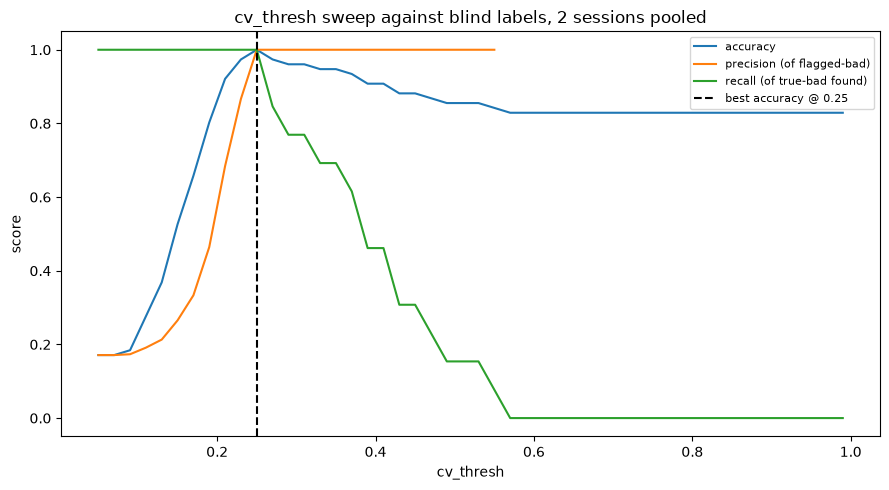

In [163]:
def evaluate_cv_thresholds(labels, pooled_cv, thresh_range):
    label_df = pd.DataFrame([{"key": k, "label": v} for k, v in labels.items()])
    labeled_df = label_df.merge(pooled_cv[["key", "session", "trial_id", "cv"]], on="key", how="inner")
    missing = len(label_df) - len(labeled_df)
    if missing:
        print(f"  {missing} labeled keys not found in pooled_cv.csv (rebuild Stage 1 for that session?) — excluded")

    rows = []
    for t in thresh_range:
        pred_bad = labeled_df["cv"] > t
        true_bad = labeled_df["label"] == "bad"
        tp = (pred_bad & true_bad).sum()
        tn = (~pred_bad & ~true_bad).sum()
        fp = (pred_bad & ~true_bad).sum()
        fn = (~pred_bad & true_bad).sum()
        accuracy = (tp + tn) / len(labeled_df)
        precision = tp / (tp + fp) if (tp + fp) > 0 else np.nan
        recall = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        rows.append({"thresh": t, "accuracy": accuracy, "precision": precision, "recall": recall})
    return labeled_df, pd.DataFrame(rows)


thresh_range = np.arange(0.05, 1.0, 0.02)
labeled_df, sweep_results = evaluate_cv_thresholds(labels, pooled_cv, thresh_range)

best_row = sweep_results.loc[sweep_results["accuracy"].idxmax()]
print(f"{len(labeled_df)} labeled trials across {labeled_df['session'].nunique()} sessions "
      f"({(labeled_df['label'] == 'good').sum()} good, {(labeled_df['label'] == 'bad').sum()} bad)")
print(f"Best accuracy {best_row['accuracy']:.1%} at cv_thresh={best_row['thresh']:.3f}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(sweep_results["thresh"], sweep_results["accuracy"], label="accuracy")
ax.plot(sweep_results["thresh"], sweep_results["precision"], label="precision (of flagged-bad)")
ax.plot(sweep_results["thresh"], sweep_results["recall"], label="recall (of true-bad found)")
ax.axvline(best_row["thresh"], color="k", linestyle="--", label=f"best accuracy @ {best_row['thresh']:.2f}")
ax.set_xlabel("cv_thresh")
ax.set_ylabel("score")
ax.set_title(f"cv_thresh sweep against blind labels, {labeled_df['session'].nunique()} sessions pooled")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

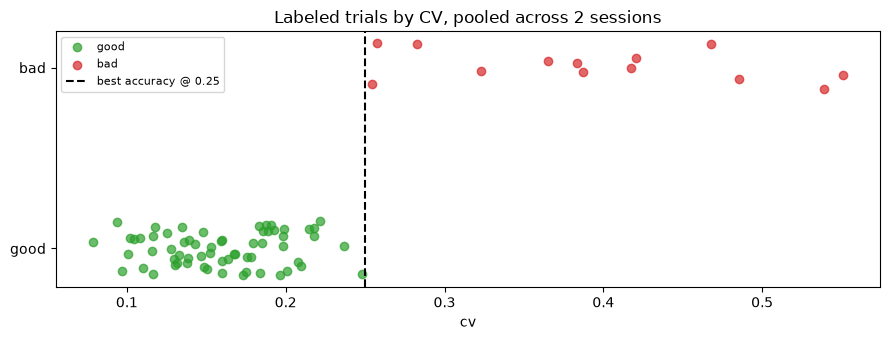

In [164]:
# Raw labeled points: each trial's actual CV, split by your label, pooled across sessions
fig, ax = plt.subplots(figsize=(9, 3.5))
rng2 = np.random.default_rng(0)
for lbl, color, y in [("good", "tab:green", 0), ("bad", "tab:red", 1)]:
    sub = labeled_df[labeled_df["label"] == lbl]
    jitter = rng2.uniform(-0.15, 0.15, len(sub))
    ax.scatter(sub["cv"], y + jitter, color=color, label=lbl, alpha=0.7)
ax.axvline(best_row["thresh"], color="k", linestyle="--", label=f"best accuracy @ {best_row['thresh']:.2f}")
ax.set_yticks([0, 1])
ax.set_yticklabels(["good", "bad"])
ax.set_xlabel("cv")
ax.set_title(f"Labeled trials by CV, pooled across {labeled_df['session'].nunique()} sessions")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## Trials that survive `cv_thresh`, pooled across sessions

Applies the accuracy-maximizing `cv_thresh` from the sweep above to the *entire* `pooled_cv` table (not just the labeled subset) and lists every surviving trial, grouped by session, so you can spot-check that they genuinely look like consistent running.

In [77]:
cv_thresh = best_row["thresh"]  # accuracy-maximizing value from the label sweep above

survived = pooled_cv[pooled_cv["cv"] <= cv_thresh].sort_values(["session", "cv"]).reset_index(drop=True)

print(f"{len(survived)} of {len(pooled_cv)} pooled trials survive cv_thresh={cv_thresh:.3f} "
      f"(mean_speed > otsu_thresh already applied per-session in Stage 1)")
for session, group in survived.groupby("session"):
    print(f"  {session}: {len(group)} trials")

survived[["session", "trial_id", "mean_speed", "cv"]]

561 of 689 pooled trials survive cv_thresh=0.230 (mean_speed > otsu_thresh already applied per-session in Stage 1)
  M061_2025_03_06_14_00: 241 trials
  M106_2026_02_25_15_00: 320 trials


,session,trial_id,mean_speed,cv
0,M061_2025_03_06_14_00,7,7.643870,0.104539
1,M061_2025_03_06_14_00,257,7.483259,0.105532
2,M061_2025_03_06_14_00,0,7.458239,0.116617
3,M061_2025_03_06_14_00,9,8.074144,0.118061
4,M061_2025_03_06_14_00,17,7.631562,0.119056
...,...,...,...,...
556,M106_2026_02_25_15_00,232,5.317339,0.217272
557,M106_2026_02_25_15_00,358,6.512704,0.219726
558,M106_2026_02_25_15_00,131,5.896264,0.221522
559,M106_2026_02_25_15_00,186,6.030971,0.225865


## Visual check: random sample of surviving trials

Kinematics + speed for a random sample of `survived` trials, spanning sessions. Reuses `_get_session_td` from the labeling setup above, and samples grouped by session so at most one session's raw `bhv` is loaded at a time (same lazy-loading/eviction as the labeling loop).

Loading M061_2025_03_06_14_00...


C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_X might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: values_MotSen1_Y might be a time-varying field. It matches the length of all_spikes on 99.85052316890882% of trials
  warnings.warn(
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\utils.py:164: UserWarning: idx_MotSen1_

['all_spikes', 'SSp_spikes', 'VAL_spikes', 'GPe_spikes', 'CP_spikes', 'MOp_spikes']
Resulting all_spikes ephys data shape is (NxT): (11, 60000)
Resulting SSp_spikes ephys data shape is (NxT): (69, 60000)
Resulting VAL_spikes ephys data shape is (NxT): (168, 60000)
Resulting GPe_spikes ephys data shape is (NxT): (120, 60000)
Resulting CP_spikes ephys data shape is (NxT): (172, 60000)
Resulting MOp_spikes ephys data shape is (NxT): (178, 60000)
bhv column not found adding it
compute_power_in_bhv_concat_td: dropping 50 trial(s) with peak_mean_freq < 2 Hz
bhv field already present, overwriting it
Loading M106_2026_02_25_15_00...


C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'idx_before_camera_trigger', 'values_Sol_duration', 'values_Sol_direction'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\Users\MartinEsparzaINBRAIN\repos\pyaldata\pyaldata\data_cleaning.py:120: UserWarning: fields: ['values_before_camera_trigger', 'values_Sol_duration', 'idx_Sol_duration', 'values_Sol_direction', 'idx_Sol_direction', 'idx_sol_on'] could not be converted to int.
  utils.warnings.warn(f"fields: {bad_fields} could not be converted to int.")
C:\

['CP_spikes', 'MOp_spikes', 'all_spikes', 'VAL_spikes', 'SSp_spikes']
Resulting CP_spikes ephys data shape is (NxT): (206, 48000)
Resulting MOp_spikes ephys data shape is (NxT): (156, 48000)
Resulting all_spikes ephys data shape is (NxT): (11, 48000)
Resulting VAL_spikes ephys data shape is (NxT): (132, 48000)
Resulting SSp_spikes ephys data shape is (NxT): (142, 48000)
bhv column not found adding it
add_concat_perturb_time: dropping 1 trial(s) with missing idx_sol_on
compute_power_in_bhv_concat_td: dropping 73 trial(s) with peak_mean_freq < 2 Hz


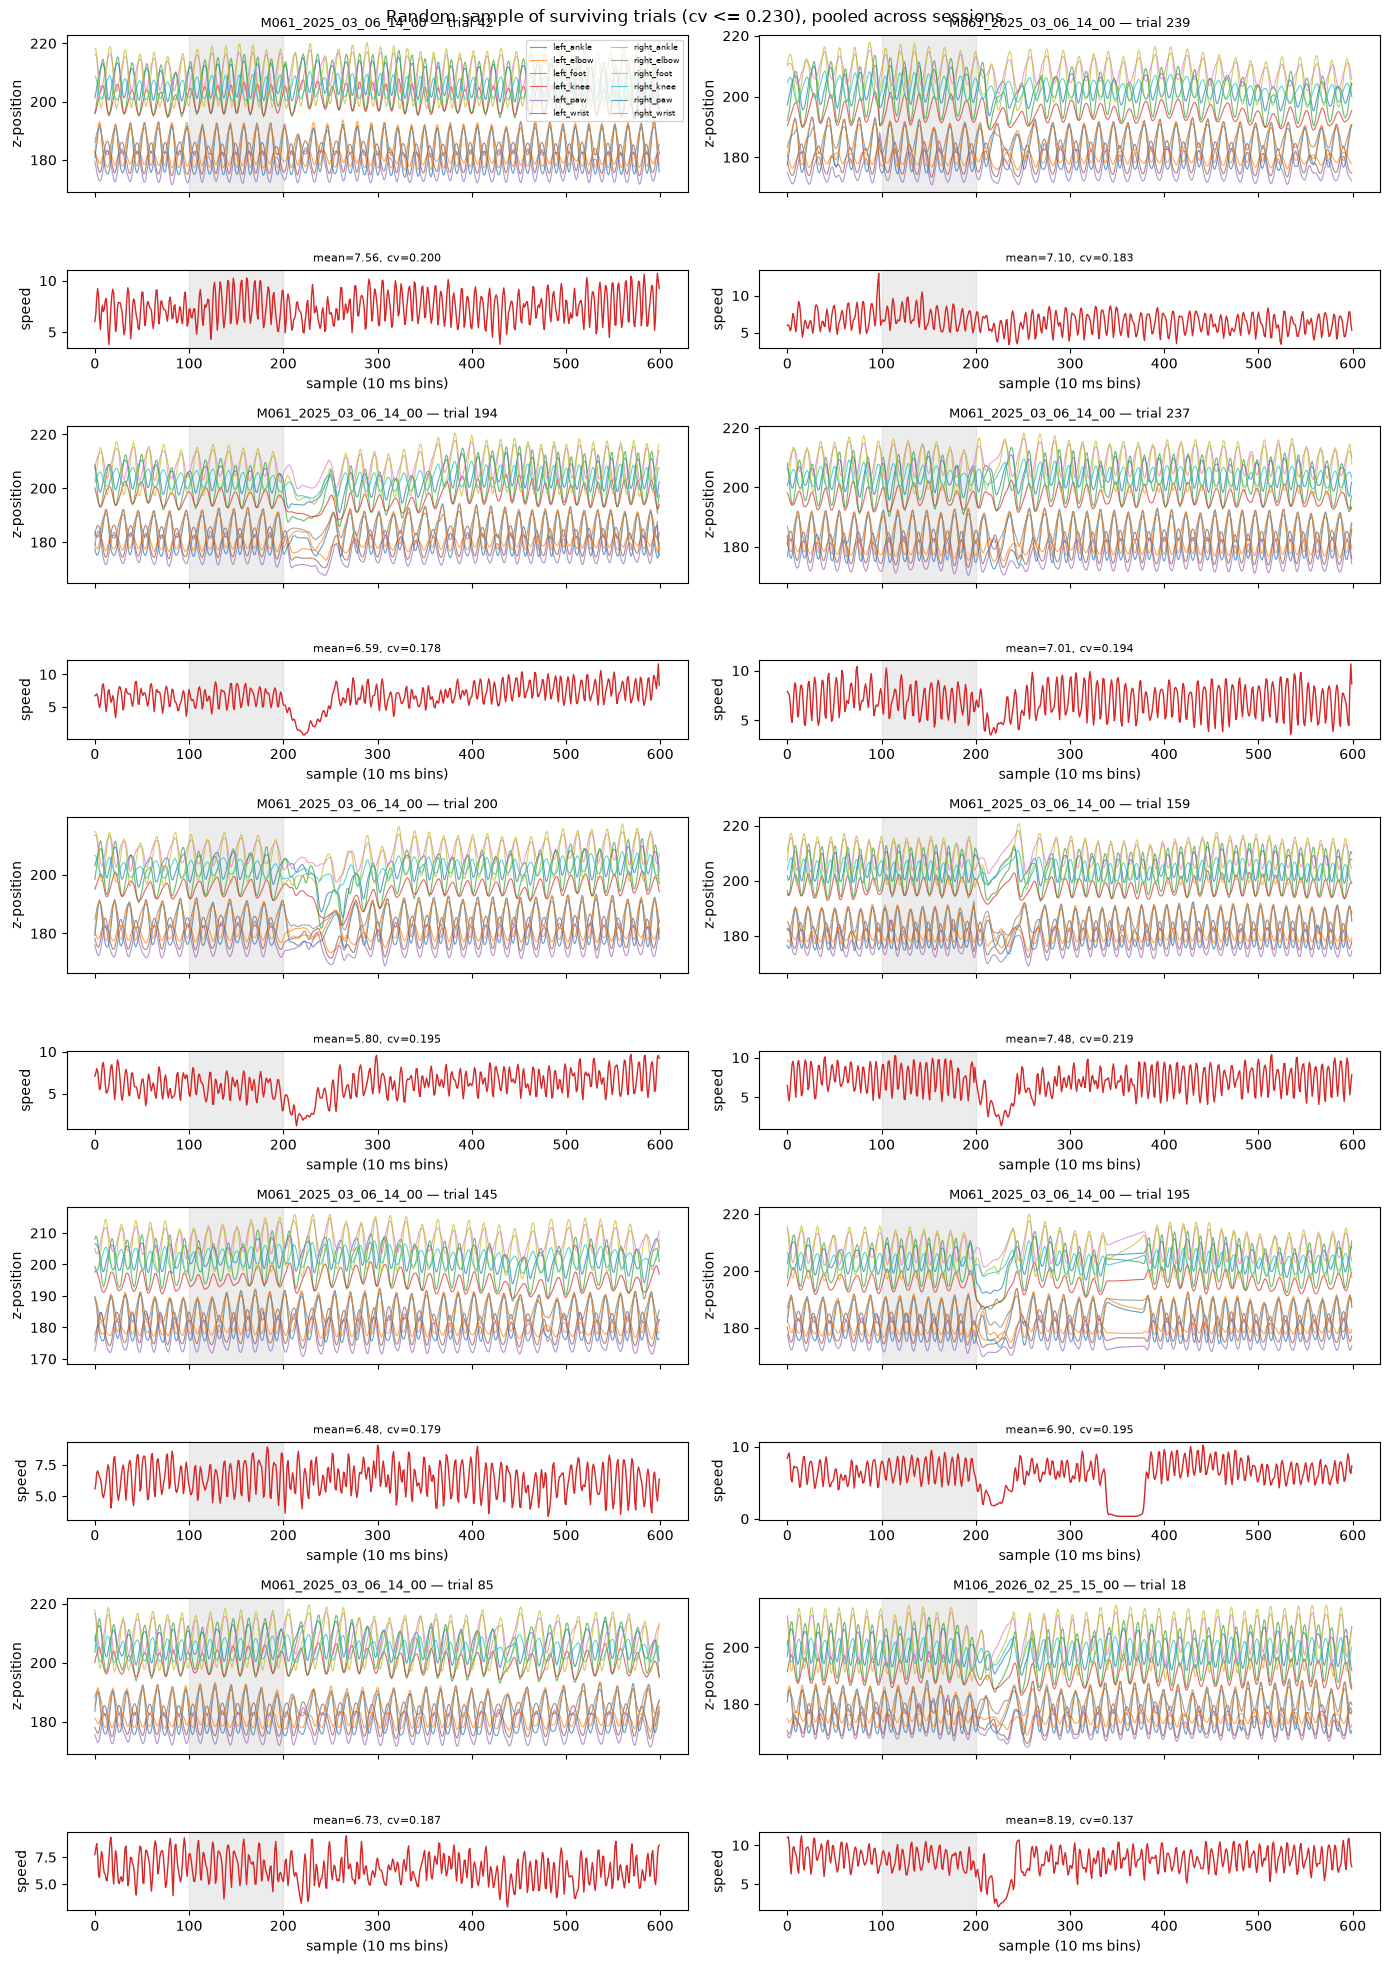

In [78]:
n_show = min(10, len(survived))
# group by session (not shuffled) so _get_session_td below doesn't thrash between sessions
show_sample = survived.sample(n=n_show, random_state=2).sort_values("session").reset_index(drop=True)

z_col_idx = np.arange(start=2, stop=len(Params.oscillating_keypoints) * 3, step=3)
ncols = 2
nrows_trials = int(np.ceil(n_show / ncols))
fig, axs = plt.subplots(
    nrows_trials * 2, ncols, figsize=(14, 4 * nrows_trials), sharex=False,
    gridspec_kw={"height_ratios": [2, 1] * nrows_trials},
)
axs = np.atleast_2d(axs)

for i, rec in enumerate(show_sample.itertuples()):
    block, col = divmod(i, ncols)
    ax_kin = axs[block * 2, col]
    ax_speed = axs[block * 2 + 1, col]

    session, trial_id = rec.session, int(rec.trial_id)
    trial_td = _get_session_td(session)
    row = trial_td.loc[trial_id]
    vel = np.gradient(row.bhv, axis=0)
    speed = np.linalg.norm(vel, axis=1)
    window = speed[100:200]
    m, c = window.mean(), window.std() / window.mean()

    for z_idx, kp in zip(z_col_idx, Params.oscillating_keypoints):
        ax_kin.plot(row.bhv[:, z_idx], label=kp, alpha=0.7, lw=0.8)
    ax_kin.axvspan(100, 200, color="gray", alpha=0.15)
    ax_kin.set_title(f"{session} — trial {trial_id}", fontsize=9)
    ax_kin.set_ylabel("z-position")
    ax_kin.tick_params(labelbottom=False)

    ax_speed.plot(speed, color="tab:red", lw=1)
    ax_speed.axvspan(100, 200, color="gray", alpha=0.15)
    ax_speed.set_ylabel("speed")
    ax_speed.set_xlabel("sample (10 ms bins)")
    ax_speed.set_title(f"mean={m:.2f}, cv={c:.3f}", fontsize=8)

for j in range(n_show, nrows_trials * ncols):
    block, col = divmod(j, ncols)
    axs[block * 2, col].axis("off")
    axs[block * 2 + 1, col].axis("off")

axs[0, 0].legend(fontsize=6, ncol=2, loc="upper right")
fig.suptitle(f"Random sample of surviving trials (cv <= {cv_thresh:.3f}), pooled across sessions")
plt.tight_layout()
plt.show()